# **APRENDIZAGEM SUPERVISIONADA: CLASSIFICAÇÃO**

Este notebook tem por objetivo demonstrar o treinamento e a avaliação de um algoritmo de Machine Learning de classificação.

Os dados são gerados artificialmente com `sklearn.datasets.make_moons`, que cria duas classes em formato de "lua" entrelaçadas — de propósito, NÃO separáveis por uma única reta. Isso deixa visualmente clara a diferença entre as fronteiras de decisão de cada família de classificador:

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

# **PRÉ-PROCESSAMENTO**

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Dataset sintetico: duas classes em forma de "lua", que NAO podem ser
# separadas por uma unica reta - de proposito, para expor a diferenca
# entre fronteiras lineares e nao lineares.
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

In [3]:
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['classe'] = y
df.head()

,x1,x2,classe
0,0.864396,-0.264509,1
1,2.451154,-0.117550,1
2,-0.350712,0.449211,1
3,0.741296,0.432919,0
4,1.188756,-0.518301,1


In [4]:
df.shape

(300, 3)

In [5]:
df['classe'].value_counts()

classe
1    150
0    150
Name: count, dtype: int64

## **Separação em treino/teste e escalonamento**

In [6]:
# Separando os dados em treino (70%) e teste (30%)
x_treino, x_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=0
)

# Escalonamento ajustado (fit) SOMENTE no treino; o teste só passa por transform
scaler = StandardScaler()
x_treino = scaler.fit_transform(x_treino)
x_teste = scaler.transform(x_teste)

In [7]:
x_treino.shape

(210, 2)

In [8]:
x_teste.shape

(90, 2)

In [9]:
y_treino.shape

(210,)

In [10]:
y_teste.shape

(90,)

# **MÁQUINAS DE VETORES DE SUPORTE (SVM)**

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [11]:
from sklearn.svm import SVC

### **Validação Cruzada**

In [12]:
from sklearn.model_selection import KFold, cross_validate

In [13]:
# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [14]:
# Criação do modelo
modelo = SVC(kernel='rbf', random_state=0, C = 2)
# kernel: tipo de separação: linear, rbf, polinomial e sigmoid.
# intensidade de regularização: quanto maior, menor a regularização, margem mais estreita.

In [15]:
# Reaproveitando a separação treino/teste e o escalonamento já feitos no
# pré-processamento (x_treino, x_teste, y_treino, y_teste).

In [16]:
# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

In [17]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Acurácia de Treino (Média): 0.9027550251256283
Acurácia de Validação (Média): 0.8954545454545453


In [18]:
# Treinar com os dados de treino completo
svm = SVC(kernel='rbf', random_state=0, C = 2)
svm.fit(x_treino, y_treino)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [19]:
previsoes_svm = svm.predict(x_teste)
previsoes_svm

array([0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0])

In [20]:
y_teste

array([0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0])

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [22]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_svm) * 100.0))

Acurácia: 91.11%


In [23]:
confusion_matrix(y_teste, previsoes_svm)

array([[35,  4],
       [ 4, 47]])

In [24]:
print(classification_report(y_teste, previsoes_svm))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        39
           1       0.92      0.92      0.92        51

    accuracy                           0.91        90
   macro avg       0.91      0.91      0.91        90
weighted avg       0.91      0.91      0.91        90



Naive Bayes = 85,82% (validação cruzada), 85,71% (treino) e 86,67% (teste) - 78 acertos

SVM = 89,55% (validação cruzada), 90,00% (treino) e 91,11% (teste) - 82 acertos - SVC(kernel='rbf', random_state=0, C = 2)



**Análise dados de treino**

In [25]:
previsoes_treino = svm.predict(x_treino)

In [26]:
accuracy_score(y_treino, previsoes_treino)

0.9

### **Fronteira de decisão**

Região azul = pontos que o modelo classificaria como classe 0; região vermelha = classe 1. Os pontos são os dados de teste, coloridos pela classe REAL — pontos numa região da cor errada são os erros do modelo. Repare na curva suave e flexível, típica do kernel RBF.

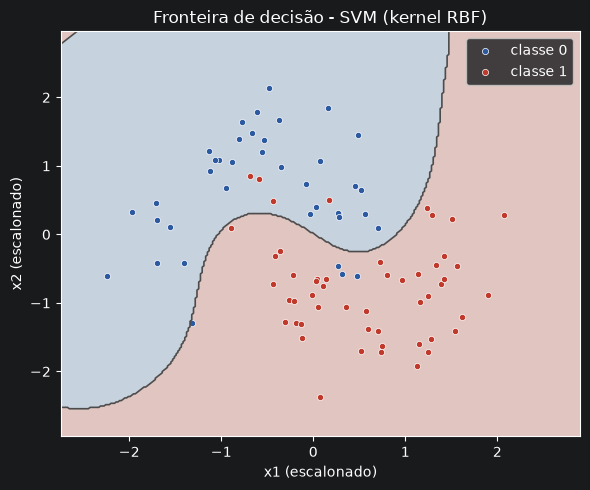

In [27]:
import matplotlib.pyplot as plt

# Malha de pontos cobrindo toda a area dos dados (treino + teste), para
# colorir cada regiao conforme a classe que o modelo preveria ali
X_plot = np.vstack([x_treino, x_teste])
xx, yy = np.meshgrid(
    np.linspace(X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5, 300),
    np.linspace(X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = svm.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=["#dbe7f6", "#f7d9d3"], alpha=0.9)
ax.contour(xx, yy, Z, levels=[0.5], colors="#4c4c4c", linewidths=1.2)

cores_pontos = ["#2c5aa0", "#c0392b"]
for classe, cor in zip([0, 1], cores_pontos):
    pts = x_teste[y_teste == classe]
    ax.scatter(pts[:, 0], pts[:, 1], c=cor, s=20, edgecolors="white",
               linewidths=0.5, label=f"classe {classe}")

ax.set_title("Fronteira de decisão - SVM (kernel RBF)")
ax.set_xlabel("x1 (escalonado)")
ax.set_ylabel("x2 (escalonado)")
ax.legend()
fig.tight_layout()
plt.show()